In [1]:
import os, re, glob, math, gzip, random
import numpy as np
import matplotlib.pyplot as plt
from collections import defaultdict
from Bio.SeqIO.FastaIO import SimpleFastaParser as sfp
import subprocess as sp
from Bio import SeqIO
import seaborn as sns
import pandas as pd

In [2]:
def cmdir(path):
    if not os.path.isdir(path):
        os.mkdir(path)

def sbatch(name, cpus, cmd):
    return "sbatch -J %s -p serc -t 1- -c %d --mem %dG --wrap '%s'" %(name, cpus, cpus*8, cmd)

In [3]:
rootdir = "/scratch/users/ajaffe/ocdata/"
cmdir(rootdir)

### read in data sources

In [4]:
reads = []

for fwd in glob.glob("/scratch/groups/dekas/OC17_metagenomics_2022/trimmed_reads/*R1*"):
    rev = fwd.replace("R1", "R2")
    reads.append((fwd, rev))
    
# display first read file pairs
reads[0]

('/scratch/groups/dekas/OC17_metagenomics_2022/trimmed_reads/3500m2000m_R1_trimmed.fastq.gz',
 '/scratch/groups/dekas/OC17_metagenomics_2022/trimmed_reads/3500m2000m_R2_trimmed.fastq.gz')

In [5]:
genome_table = pd.read_csv(rootdir + "tables/ocdata_table_s1.tsv", sep="\t")
genome_table.head()

,user_genome,original_name,secondary_cluster,classification,aai_clean,refined_nscafs,refined_binlen,checkm_completeness,checkm_redundancy,refined_gunc_css,...,OC5_1000m,OC5_2000m,OC5_3000m,OC6_50m,OC6_150m,OC6_500m,OC6_1000m,OC6_2000m,OC6_3000m,OC6_4000m
0,OC2_150m_MAG_100,A500m150m.100,61_3,d__Archaea;p__Thermoplasmatota;c__Poseidoniia;...,81.74,155,876146,52.89,0.18,0.00,...,0.194332,0.0,0.0,0.0,0.239761,1.898998,0.234011,0.0,0.0,0.0
1,OC2_150m_MAG_124,A500m150m.124,34_1,d__Archaea;p__Thermoplasmatota;c__Poseidoniia;...,82.98,105,1289673,70.48,0.48,0.07,...,0.179581,0.0,0.0,0.0,0.024227,0.395981,0.242656,0.0,0.0,0.0
2,OC2_150m_MAG_185,A500m150m.185,82_1,d__Archaea;p__Thermoplasmatota;c__Poseidoniia;...,78.35,351,1241371,65.28,2.80,0.26,...,0.000000,0.0,0.0,0.0,0.000000,0.065028,0.000000,0.0,0.0,0.0
3,OC2_150m_MAG_207,A500m150m.207,17_0,d__Archaea;p__Thermoplasmatota;c__Poseidoniia;...,79.32,334,1086583,59.03,0.00,0.00,...,0.000000,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.0,0.0,0.0
4,OC2_500m_MAG_107,A500m500m.107,665_0,d__Archaea;p__Thermoproteota;c__Nitrososphaeri...,90.00,171,798507,77.45,3.23,0.00,...,0.000000,0.0,0.0,0.0,1.862461,0.084545,0.000000,0.0,0.0,0.0


### get genome features

In [8]:
cmdir(rootdir + "genomes/checkm2")
cmdir(rootdir + "singlem")

In [9]:
with open(rootdir + "genomes/checkm2/genome_paths.txt", "w") as out:
    for path in glob.glob(rootdir + "genomes/drep/dereplicated_genomes/*"):
        out.write(path + "\n")

Then split manually: split genome_paths.txt -l 50

In [10]:
with open(rootdir + "genomes/checkm2/run_checkm2.sh", "w") as out:
    
    for batchfile in glob.glob(rootdir + "genomes/checkm2/x*"):

        cmd = "checkm2 predict --input %s --output-directory %s -x .fa --threads 20" %(" ".join([r.strip() for r in open(batchfile).readlines()]), 
            rootdir + "genomes/checkm2/" + os.path.basename(batchfile) + "_results")
        out.write(sbatch("checkm2", 20, cmd) + "\n")

In [13]:
checkm_df = pd.concat([pd.read_csv(item, sep="\t") for item in 
    glob.glob(rootdir + "genomes/checkm2/x*/quality_report.tsv")])
checkm_df.to_csv(rootdir + "singlem/singlem_checkm.tsv", sep="\t", index=False)

In [15]:
# also output taxonomy
genome_table[["user_genome", "classification"]].to_csv(rootdir + "singlem/singlem_gtdb.tsv", sep="\t", header=None, index=False)

### run singleM

In [16]:
# supplement metapackage using new genomes
cmd = "singularity run /home/groups/dekas/software/singularity/singlem_0.20.3.sif supplement \
    --new-genome-fasta-files %s --output-metapackage %s --checkm2-quality-file %s --checkm2-min-completeness 0 \
    --checkm2-max-contamination 100 --taxonomy-file %s --threads 20 \
    --no-dereplication" %(rootdir + "/genomes/drep/dereplicated_genomes/*fa", rootdir + "/singlem/updated.smpkg",
                          rootdir + "singlem/singlem_checkm.tsv", rootdir + "singlem/singlem_gtdb.tsv")
print(cmd)

singularity run /home/groups/dekas/software/singularity/singlem_0.20.3.sif supplement     --new-genome-fasta-files /scratch/users/ajaffe/ocdata//genomes/drep/dereplicated_genomes/*fa --output-metapackage /scratch/users/ajaffe/ocdata//singlem/updated.smpkg --checkm2-quality-file /scratch/users/ajaffe/ocdata/singlem/singlem_checkm.tsv --checkm2-min-completeness 0     --checkm2-max-contamination 100 --taxonomy-file /scratch/users/ajaffe/ocdata/singlem/singlem_gtdb.tsv --threads 20     --no-dereplication


In [ ]:
# process samples
with open(rootdir + "singlem/pipe.sh", "w") as out:
    for read_tuple in reads:
        
        name = os.path.basename(read_tuple[0]).split("_")[0]   
        cmd = "singularity run /home/groups/dekas/software/singularity/singlem_0.20.3.sif pipe \
            -1 %s -2 %s -p %s --otu-table %s --threads 20 --assignment-method diamond --metapackage %s" %(read_tuple[0], read_tuple[1],
             rootdir + "singlem/" + name + ".prof.tsv", rootdir + "singlem/" + name + ".otu.tsv", rootdir + "/singlem/updated.smpkg")
        out.write(sbatch(name, 20, cmd) + "\n")

In [ ]:
# compute microbial fraction
with open(rootdir + "singlem/mf.sh", "w") as out:
    for read_tuple in reads:
        name = os.path.basename(read_tuple[0]).split("_")[0]
        cmd = "singularity run /home/groups/dekas/software/singularity/singlem_0.20.3.sif prokaryotic_fraction \
                -1 %s -2 %s -p %s --output-tsv %s --metapackage %s" %(read_tuple[0], read_tuple[1], rootdir + "singlem/" + name + ".prof.tsv",
                                                    rootdir + "singlem/" + name + ".pf.tsv", rootdir + "/singlem/updated.smpkg")
        out.write(sbatch(name, 20,cmd) + "\n")

### visualize community composition

In [134]:
site_dict = {"500":"OC2", "3000":"OC3", 
             "3500":"OC4", "4000":"OC5", "4500": "OC6"}

def assign_lineage(taxstring):
    
    if "p__" not in taxstring:
        return "other"
    elif taxstring == "Root; d__Bacteria; p__Pseudomonadota":
        return "other"
    elif "Pseudomonadota" in taxstring:
        return taxstring.split(";")[3].replace(" c__", "")
    else:
        return taxstring.split(";")[2].replace(" p__", "")

In [143]:
profiles = pd.concat(pd.read_csv(item, sep="\t") for item in \
                     glob.glob(rootdir + "singlem/*prof*") if "A" not in item)
profiles["clean_sample"] = profiles["sample"].apply(lambda x: site_dict[x.split("m")[0]] + \
                                                    "_" + x.split("m")[1] + "m")
totals = profiles.groupby("clean_sample", as_index=False).aggregate({"coverage":"sum"}).rename(columns={"coverage":"total_coverage"})
profiles["lineage"] = profiles["taxonomy"].apply(lambda x: assign_lineage(x))
profgb = profiles.groupby(["clean_sample", "lineage"], as_index=False).aggregate({"coverage":"sum"})
profgb = profgb.merge(totals, how="left", on="clean_sample")
profgb["perc_rel_cov"] = profgb.apply(lambda x: x["coverage"]/x["total_coverage"]*100, axis=1)
profgb.head()

,clean_sample,lineage,coverage,total_coverage,perc_rel_cov
0,OC2_150m,Acidobacteriota,69.42,15908.82,0.436362
1,OC2_150m,Actinomycetota,738.82,15908.82,4.644091
2,OC2_150m,Alphaproteobacteria,3096.89,15908.82,19.466497
3,OC2_150m,Armatimonadota,0.50,15908.82,0.003143
4,OC2_150m,Asgardarchaeota,0.42,15908.82,0.002640


In [144]:
def generate_color():
    return "#" + "%06x" % random.randint(0, 0xFFFFFF)

colors = {}
for item in profgb["lineage"].unique():
    colors[item] = generate_color()

In [3]:
sns.color_palette("tab20c")

[(0.19215686274509805, 0.5098039215686274, 0.7411764705882353),
 (0.4196078431372549, 0.6823529411764706, 0.8392156862745098),
 (0.6196078431372549, 0.792156862745098, 0.8823529411764706),
 (0.7764705882352941, 0.8588235294117647, 0.9372549019607843),
 (0.9019607843137255, 0.3333333333333333, 0.050980392156862744),
 (0.9921568627450981, 0.5529411764705883, 0.23529411764705882),
 (0.9921568627450981, 0.6823529411764706, 0.4196078431372549),
 (0.9921568627450981, 0.8156862745098039, 0.6352941176470588),
 (0.19215686274509805, 0.6392156862745098, 0.32941176470588235),
 (0.4549019607843137, 0.7686274509803922, 0.4627450980392157),
 (0.6313725490196078, 0.8509803921568627, 0.6078431372549019),
 (0.7803921568627451, 0.9137254901960784, 0.7529411764705882),
 (0.4588235294117647, 0.4196078431372549, 0.6941176470588235),
 (0.6196078431372549, 0.6039215686274509, 0.7843137254901961),
 (0.7372549019607844, 0.7411764705882353, 0.8627450980392157),
 (0.8549019607843137, 0.8549019607843137, 0.9215686274509803),
 (0.38823529411764707, 0.38823529411764707, 0.38823529411764707),
 (0.5882352941176471, 0.5882352941176471, 0.5882352941176471),
 (0.7411764705882353, 0.7411764705882353, 0.7411764705882353),
 (0.8509803921568627, 0.8509803921568627, 0.8509803921568627)]

In [146]:
# expects table `run\tphylum\tperc_total`
def plot_stacked_bar(input_data, color_dict):
    
    # pivot out
    input_pivot = input_data.pivot("clean_sample", "lineage", "perc_rel_cov").fillna(0)
    # define phylum order
    lineage_order = input_data.query("lineage != 'other'").groupby("lineage", as_index=False) \
        .aggregate({"perc_rel_cov":"median"}).sort_values("perc_rel_cov", ascending=False)["lineage"].to_list()
    # get top taxa to display
    top_taxa = input_data.query("lineage!='other'").groupby("lineage", as_index=False) \
        .aggregate({"perc_rel_cov":"median"}).sort_values("perc_rel_cov", ascending=False)[0:15]["lineage"].to_list()
    #top_taxa.append("Cyanobacteriota")
    # move 'other' if needed
    if "other" in input_data["lineage"].unique():
        lineage_order.insert(max([lineage_order.index(item) for item in top_taxa])+1, "other")
    # generate final color map
    #color_map = [color_dict[item] if item in top_taxa else "lightgrey" for item in lineage_order]
    color_map = [sns.color_palette("tab20c")[i] if item in top_taxa else "lightgrey" for i, item in enumerate(lineage_order)]
    # define sample order
    sample_order = sorted(profgb["clean_sample"].unique(), 
                        key = lambda x: (int(x.split("_")[1].replace("m","")), x.split("_")[0], ), reverse=True)
    
    ## plot
    sns.set_style("ticks")
    input_pivot.loc[sample_order,lineage_order].plot.barh(color=color_map, width=0.85,stacked=True, 
        linewidth=0.3, figsize=(6,10), legend=None)
    plt.xlabel("relative abundance (%)")
    plt.legend(bbox_to_anchor=(1, 1), loc='upper left', fontsize=9)
    plt.ylabel("")
    sns.despine(bottom="True", left=True)

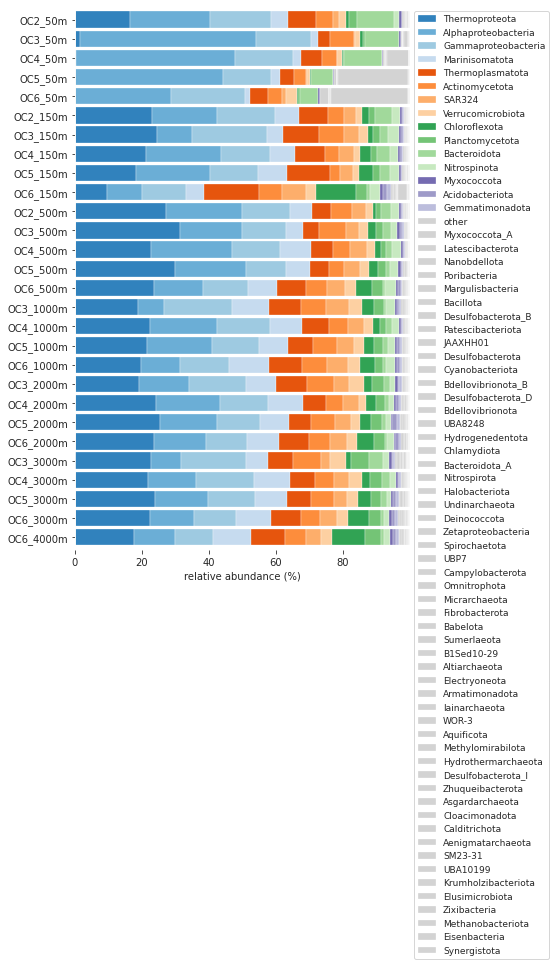

In [147]:
plot_stacked_bar(profgb, colors)
plt.savefig(rootdir + "figures/community_barplots.svg", format="svg")
plt.show()

### binning effort visuals

In [6]:
site_dict = {"500":"OC2", "3000":"OC3", 
             "3500":"OC4", "4000":"OC5", "4500": "OC6"}

In [7]:
covtable = pd.read_csv(rootdir + "/tables/genome_coverage_info.0.csv", sep="\t")
covtable["updated_sample"] = covtable["Sample"].apply(lambda x: \
    site_dict[x.split("_")[1].split("m")[0].replace("R", "")] + "_" + x.split("_")[1].split("m")[1] + "m")
covtotals = covtable.groupby("updated_sample", as_index=False).aggregate({"Read Count": "sum"}).rename(columns={"Read Count": "genome_read_count"})
covtotals.head()

,updated_sample,genome_read_count
0,OC2_150m,110743887
1,OC2_500m,76689252
2,OC2_50m,84914985
3,OC3_1000m,168361176
4,OC3_150m,162990806


In [8]:
sample_reads = pd.read_csv(rootdir + "tables/read_trimming_info.tsv", sep="\t")
sample_reads["updated_sample"] = sample_reads["clean_sample"].apply(lambda x: site_dict[x.split("m")[0]] + \
                                                                    "_" + x.split("m")[1] + "m")
sample_reads = sample_reads[["updated_sample", "trimmed_read_pairs"]]
sample_reads.head(2)

,updated_sample,trimmed_read_pairs
0,OC6_4000m,220806306
1,OC2_500m,170083394


In [9]:
fracs = pd.concat(pd.read_csv(item, sep="\t") for item in glob.glob(rootdir + "/singlem/*.pf.tsv"))
fracs["updated_sample"] = fracs["sample"].apply(lambda x: site_dict[x.split("m")[0]] + \
                                                    "_" + x.split("m")[1] + "m")
fracs = fracs.merge(sample_reads, how="left", on="updated_sample")
merged = fracs[["updated_sample", "bacterial_archaeal_bases", "metagenome_size", 
       "trimmed_read_pairs", "read_fraction"]].merge(covtotals, how="left", on="updated_sample")
merged["trimmed_read_total"] = merged["trimmed_read_pairs"].apply(lambda x: x*2)
merged["genome_read_perc"] = merged.apply(lambda x: 100*(x["genome_read_count"]/x["trimmed_read_total"]), axis=1)
merged["domain_adjusted"] = merged.apply(lambda x: 100*(x["genome_read_perc"]/x["read_fraction"]), axis=1)
merged["depth"] = merged["updated_sample"].apply(lambda x: x.split("_")[1])
merged.head(2)

,updated_sample,bacterial_archaeal_bases,metagenome_size,trimmed_read_pairs,read_fraction,genome_read_count,trimmed_read_total,genome_read_perc,domain_adjusted,depth
0,OC5_150m,25899934549,37903931474,156173673,68.33,93543471,312347346,29.94854,43.829270,150m
1,OC6_500m,37723529323,52479401136,189482972,71.88,140845423,378965944,37.16572,51.705231,500m


/home/users/ajaffe/.local/lib/python3.6/site-packages/seaborn/_decorators.py:43: FutureWarning: Pass the following variables as keyword args: x, y. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  FutureWarning


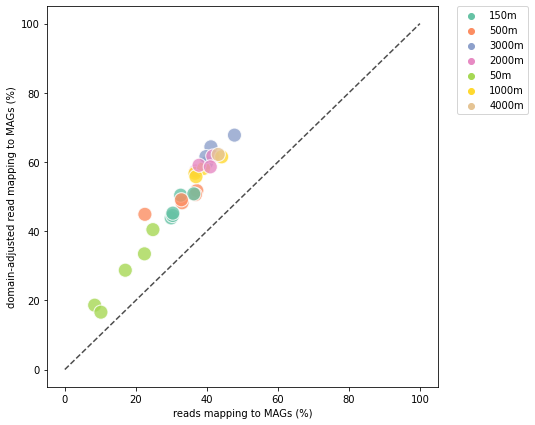

In [10]:
plt.figure(figsize=[7,7])
sns.scatterplot("genome_read_perc", "domain_adjusted", data=merged, hue="depth",
    palette="Set2", s=200, alpha=0.8)
plt.legend(bbox_to_anchor=(1.05, 1), loc=2, borderaxespad=0.)
plt.plot([0,100],[0,100],  ls="--", c=".3")
plt.ylabel("domain-adjusted read mapping to MAGs (%)")
plt.xlabel("reads mapping to MAGs (%)")
plt.show()

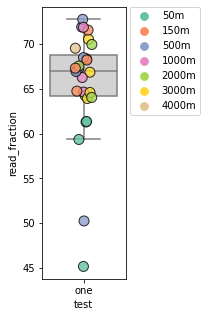

In [11]:
merged["test"] = "one"
plt.figure(figsize=[1.5,5])
depth_order = sorted(set(merged["depth"]), key=lambda x: int(x.replace("m","")))
sns.boxplot(x="test", y="read_fraction", data=merged, color="lightgrey", fliersize=0)
sns.stripplot(x="test", y="read_fraction", hue="depth", hue_order=depth_order,
            data=merged, palette="Set2", dodge=False, 
            linewidth=1, edgecolor="black", alpha=0.8, size=10, jitter=0.1)
plt.legend(bbox_to_anchor=(1.05, 1), loc=2, borderaxespad=0.)
plt.savefig(rootdir + "figures/read_fraction.svg", format="svg")
plt.show()

In [12]:
#assemblies
amapping = pd.concat([pd.read_csv(item, sep="\t") for item in glob.glob(rootdir + "tables/A*_info.csv")])
amapping["updated_sample"] = amapping["Sample"].apply(lambda x: site_dict[x.split("m")[0].replace("A","")] + \
                                                    "_" + x.split("m")[1] + "m")
a_groupby = amapping.groupby("updated_sample", as_index=False).aggregate({"Read Count": "sum"}).rename(columns={"Read Count":"assembly_read_count"})
a_groupby.head(2)

,updated_sample,assembly_read_count
0,OC2_150m,197686063
1,OC2_500m,169537480


/home/users/ajaffe/.local/lib/python3.6/site-packages/seaborn/_decorators.py:43: FutureWarning: Pass the following variables as keyword args: x, y. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  FutureWarning


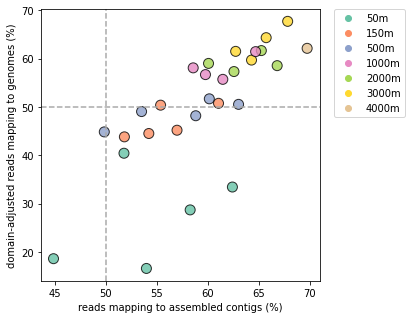

In [13]:
merged = merged.merge(a_groupby, how="left", on="updated_sample")
merged["assembly_read_perc"] = merged.apply(lambda x: 100*(x["assembly_read_count"]/x["trimmed_read_total"]), axis=1)

plt.figure(figsize=[5,5])
kws = {"ec":"black", "linewidth":1}
sns.scatterplot("assembly_read_perc", "domain_adjusted", data=merged, hue="depth",
    hue_order = depth_order, palette="Set2", s=100, alpha=0.8, **kws)
plt.legend(bbox_to_anchor=(1.05, 1), loc=2, borderaxespad=0.)
plt.axvline(50, ls="--", c="darkgrey")
plt.axhline(50, ls="--", c="darkgrey")
plt.ylabel("domain-adjusted reads mapping to genomes (%)")
plt.xlabel("reads mapping to assembled contigs (%)")
plt.savefig(rootdir + "figures/assembly_binning_effort.svg", format="svg")
plt.show()

### appraise

In [63]:
# first run pipe on genomes
cmd = "singularity run /home/groups/dekas/software/singularity/singlem_0.20.3.sif pipe \
    --genome-fasta-files %s --otu-table %s --threads 20 \
    --assignment-method diamond --metapackage %s" %(rootdir + "/genomes/drep/dereplicated_genomes/*fa",
                                                    rootdir + "singlem/genomes.otu.tsv",
                                                    rootdir + "/singlem/updated.smpkg")
print(sbatch("genome", 20, cmd))

sbatch -J genome -p serc -t 1- -c 20 --mem 160G --wrap 'singularity run /home/groups/dekas/software/singularity/singlem_0.20.3.sif pipe     --genome-fasta-files /scratch/users/ajaffe/ocdata//genomes/drep/dereplicated_genomes/*fa --otu-table /scratch/users/ajaffe/ocdata/singlem/genomes.otu.tsv --threads 20     --assignment-method diamond --metapackage /scratch/users/ajaffe/ocdata//singlem/updated.smpkg'


In [65]:
# then run pipe on assemblies
with open(rootdir + "singlem/pipe_assemblies.sh", "w") as out:
    for assembly in glob.glob("/scratch/groups/dekas/OC17_metagenomics_2022/assemblies/*"):
        name = "A" + "".join(os.path.basename(assembly).split("_")[1:3])
        cmd = "singularity run /home/groups/dekas/software/singularity/singlem_0.20.3.sif pipe \
            --sequences %s -p %s --otu-table %s --threads 20 --assignment-method diamond --metapackage %s" %(assembly,
             rootdir + "singlem/" + name + ".prof.tsv", rootdir + "singlem/" + name + ".otu.tsv", rootdir + "/singlem/updated.smpkg")
        out.write(sbatch(name, 20, cmd) + "\n")

In [17]:
with open(rootdir + "singlem/appraise.sh", "w") as out:
    
    for assembly_otu in glob.glob(rootdir + "singlem/A*.otu.tsv"):
        
        if ("genome" not in assembly_otu):
            
            name = os.path.basename(assembly_otu).split(".")[0].replace("A","")
            # appraise
            cmd = "singularity run /home/groups/dekas/software/singularity/singlem_0.20.3.sif appraise \
                    --metagenome-otu-tables %s --genome-otu-tables %s --assembly-otu-tables %s --imperfect --plot %s \
                    --output-binned-otu-table %s --output-unbinned-otu-table %s --output-unaccounted-for-otu-table %s --metapackage %s" %(assembly_otu.replace("A",""),
                        rootdir + "singlem/genomes.otu.tsv", assembly_otu, rootdir + "singlem/" + name + ".svg", 
                        rootdir + "singlem/" + name + ".binned.tsv", rootdir + "singlem/" + name + ".unbinned.tsv", 
                        rootdir + "singlem/" + name + ".unaccounted.tsv", rootdir + "/singlem/updated.smpkg")
            out.write(cmd + "\n")

In [77]:
processed_tables = []

for otu in glob.glob(rootdir + "singlem/*.otu.tsv"):
    
    if ("A" not in otu) and ("genome" not in otu):
        
        result = {}
        
        for level in ["unaccounted", "unbinned", "binned"]:
            for key, row in pd.read_csv(otu.replace("otu", 
                level), sep="\t").query("gene=='S3.1.ribosomal_protein_L2_rplB'").iterrows():
                result[row["sequence"]] = level
        
        table = pd.read_csv(otu, sep="\t")
        # remove euks/no discernable taxonomy, filter down to arb. marker gene
        table = table[(~table["taxonomy"].str.contains("Eukaryota")) & \
                      (table["taxonomy"] != 'Root') & \
                      (table["gene"]=='S3.1.ribosomal_protein_L2_rplB')]
        table["result"] = table["sequence"].map(result).fillna("None")
        processed_tables.append(table)
        
all_tables = pd.concat(processed_tables)
all_tables.head(2)

,gene,sample,sequence,num_hits,coverage,taxonomy,result
0,S3.1.ribosomal_protein_L2_rplB,3000m150m_R1_trimmed,GAACTAAAGCAAGGCAAAGGCGGTCAAATCGCCCGTGCCGCTGGTA...,1,1.64,Root; d__Bacteria; p__Pseudomonadota; c__Alpha...,unaccounted
1,S3.1.ribosomal_protein_L2_rplB,3000m150m_R1_trimmed,GAACAGCAATTTGGAGATGGTGGTGCATTGATGAAATCCGCAGGTG...,5,8.43,Root; d__Archaea; p__Thermoproteota; c__Nitros...,unaccounted


In [78]:
# compute per otu results percs
otu_info = defaultdict(list)

for otu in all_tables["sequence"].unique():
    
    subtable = all_tables[all_tables["sequence"]==otu]
    observations = subtable.shape[0]
    
    otu_info["gene"].append('S3.1.ribosomal_protein_L2_rplB')
    otu_info["otu_sequence"].append(otu)
    otu_info["num_samples_observed"].append(observations)
    otu_info["otu_taxonomy"].append(subtable["taxonomy"].iloc[0])
    
    for level in ["unaccounted", "unbinned", "binned"]:
        
        level_count = subtable[subtable["result"]==level].shape[0]
        otu_info[level + "_frequency"].append(100*(level_count/observations))
    
otu_df = pd.DataFrame(otu_info)
otu_df.head(2)

,gene,otu_sequence,num_samples_observed,otu_taxonomy,unaccounted_frequency,unbinned_frequency,binned_frequency
0,S3.1.ribosomal_protein_L2_rplB,GAACTAAAGCAAGGCAAAGGCGGTCAAATCGCCCGTGCCGCTGGTA...,1,Root; d__Bacteria; p__Pseudomonadota; c__Alpha...,100.000000,0.000000,0.0
1,S3.1.ribosomal_protein_L2_rplB,GAACAGCAATTTGGAGATGGTGGTGCATTGATGAAATCCGCAGGTG...,3,Root; d__Archaea; p__Thermoproteota; c__Nitros...,66.666667,33.333333,0.0


### export

In [98]:
# singlem pipe
profiles[["clean_sample", "taxonomy", "lineage", "coverage"]].to_csv(rootdir + "tables/singlem_read_pipe_results.tsv", sep="\t", index=False)

In [14]:
# sample level data
read_metadata = pd.read_csv(rootdir + "tables/read_trimming_info.tsv", sep="\t")
read_metadata["updated_sample"] = read_metadata["clean_sample"].apply(lambda x: site_dict[x.split("m")[0]] + \
                                                                    "_" + x.split("m")[1] + "m")
base = merged.merge(read_metadata[["updated_sample", "raw_read_pairs", "percent_read_pairs_removed"]],
                    how="left", on="updated_sample")
base[["updated_sample", "raw_read_pairs", "trimmed_read_pairs", "percent_read_pairs_removed",
      "assembly_read_count", "assembly_read_perc", "genome_read_count", "genome_read_perc", 
      "read_fraction"]].to_csv(rootdir + "tables/sample_level_characteristics.tsv", sep="\t", index=False)

In [97]:
# sorted appraise table, subset
otu_df["percent_samples_observed"] = otu_df["num_samples_observed"].apply(lambda x: (x/28)*100)
otu_df.query("percent_samples_observed>=25").sort_values(["binned_frequency", "unaccounted_frequency", 
    "num_samples_observed"], ascending=[True, False, False]).to_csv(rootdir + "tables/appraise_results_subset.tsv", sep="\t", index=False)